<a href="https://colab.research.google.com/github/gunaanand08/Ioe/blob/main/Experiment2a.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

    Time  Soil Moisture  Soil pH  Water Level        Status
3      4           20.3      6.3         19.9  LOW MOISTURE
4      5           26.5      8.2         73.3  LOW MOISTURE
5      6           65.7      6.0         76.0        NORMAL
6      7           36.3      6.5         21.4        NORMAL
7      8           49.9      8.1         83.0        NORMAL
8      9           24.1      7.0         80.2  LOW MOISTURE
9     10           70.7      5.9         41.8        NORMAL
10    11           69.2      5.7         96.0        NORMAL
11    12           80.2      7.8         81.6        NORMAL
12    13           37.1      6.1         25.2        NORMAL

Average Moisture : 45.52
Average pH       : 6.74
Average Water    : 63.07


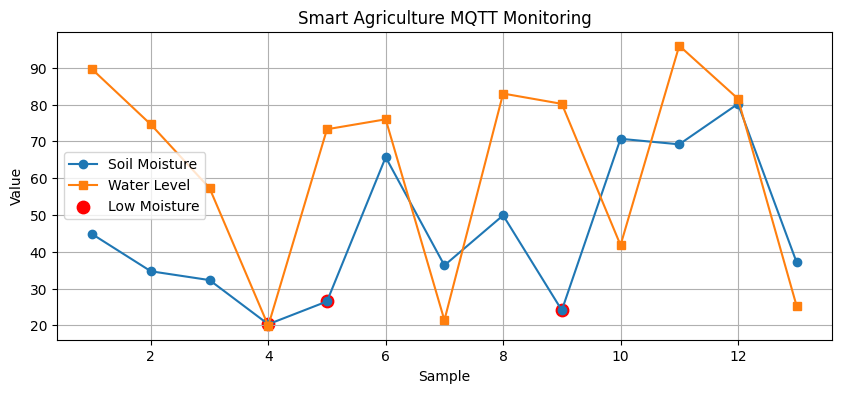

KeyboardInterrupt: 

In [ ]:
import paho.mqtt.client as mqtt
import json
import random
import threading
import time
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import clear_output

# MQTT Configuration
BROKER = "broker.hivemq.com"
PORT = 1883
TOPIC = "IoT_AI_LAB/SmartAgriculture"

# Data Storage
moisture_data = []
ph_data = []
water_level_data = []
timestamps = []

# MQTT Clients
publisher = mqtt.Client(mqtt.CallbackAPIVersion.VERSION1)
subscriber = mqtt.Client(mqtt.CallbackAPIVersion.VERSION1)

# Publisher
def start_publisher():
    publisher.connect(BROKER, PORT, 60)
    publisher.loop_start()

    while True:
        moisture = round(random.uniform(20, 90), 1)
        ph = round(random.uniform(5.5, 8.5), 1)
        water = round(random.uniform(15, 100), 1)

        payload = {
            "soil_moisture": moisture,
            "soil_ph": ph,
            "water_level": water
        }

        publisher.publish(TOPIC, json.dumps(payload))
        time.sleep(1)

# Subscriber
def on_connect(client, userdata, flags, rc):
    print("Connected:", rc)
    client.subscribe(TOPIC)

def on_message(client, userdata, msg):
    data = json.loads(msg.payload.decode())

    moisture_data.append(data["soil_moisture"])
    ph_data.append(data["soil_ph"])
    water_level_data.append(data["water_level"])
    timestamps.append(len(timestamps) + 1)

subscriber.on_connect = on_connect
subscriber.on_message = on_message

subscriber.connect(BROKER, PORT, 60)

threading.Thread(target=start_publisher, daemon=True).start()
subscriber.loop_start()

# Run only 30 updates (works well in Colab)
for _ in range(30):

    time.sleep(2)

    if len(moisture_data) == 0:
        continue

    clear_output(wait=True)

    df = pd.DataFrame({
        "Time": timestamps,
        "Soil Moisture": moisture_data,
        "Soil pH": ph_data,
        "Water Level": water_level_data
    })

    df["Status"] = df["Soil Moisture"].apply(
        lambda x: "LOW MOISTURE" if x < 30 else "NORMAL"
    )

    print(df.tail(10))

    print("\nAverage Moisture :", round(df["Soil Moisture"].mean(),2))
    print("Average pH       :", round(df["Soil pH"].mean(),2))
    print("Average Water    :", round(df["Water Level"].mean(),2))

    plt.figure(figsize=(10,4))

    plt.plot(df["Time"], df["Soil Moisture"], marker="o", label="Soil Moisture")
    plt.plot(df["Time"], df["Water Level"], marker="s", label="Water Level")

    low = df[df["Status"]=="LOW MOISTURE"]

    plt.scatter(low["Time"], low["Soil Moisture"],
                color="red", s=80, label="Low Moisture")

    plt.xlabel("Sample")
    plt.ylabel("Value")
    plt.title("Smart Agriculture MQTT Monitoring")
    plt.grid(True)
    plt.legend()
    plt.show()

subscriber.loop_stop()
publisher.loop_stop()

print("Experiment Completed Successfully")